# STINTSY Major Course Output

### Group 3
### Members:

* Rohann Gabriel D. Dizon
* Rainier A. Dulatre

### Dataset Description

* The dataset comprises competitive gameplay statistics sourced from **Tetrio**, a modern, fast-paced multiplayer Tetris clone. It specifically tracks the performance and match data of the top 500 players in the Tetra League. The data is scraped from 61,935 match replays of the top 500 Tetra League players between January 22, 2024, and January 30, 2024.

* Source: Kaggle (https://www.kaggle.com/datasets/n3koasakura/tetr-io-top-players-replays/data)

### Structure of the Data
* ##### **Unit of Analysis**: Each individual row represents a single subframe piece placement (one block dropped) 
* ##### **Number of Observations/Rows**: 7,716,524 piece placements.
* ##### **Format**: Tabular data with 21 variables/columns.

* ### Description of Variables

| **Features/Variables** | **Description** |
|------------------------|-----------------|
| game_id | The unique ID for this game/replay (players in the same match get different IDs). |
| subframe | The subframe of this placement. There 60 frames per second and 10 subframes per frame, or 600 subframes per second, starting with subframe 0. |
| won | 1 if this placement is part of a replay that won its match. Otherwise, 0. |
| playfield | The 10x40 playfield right before the placement occured. The cells of the playfield are ordered left to right, bottom to top. The playfield is truncated once all the remaining cells are empty. An empty string is not a missing value, but instead represents a playfield where all cells are empty. Each cell is represented with the letter of its corresponding tetrimino, except for empty and garbage cells, which are represented with "N" and "G" respectively. |
| x | The x-coordinate of the center of the placed piece according to the "true rotations" used in the Super Rotation System. 0 indicates the leftmost column, 9 indicates the rightmost column. |
| y | The y-coordinate of the center of the placed piece according to the "true rotations" used in the Super Rotation System. 0 indicates the bottommost row, 39 indicates the topmost row. |
| r | The rotation of the placed piece according to the Super Rotation System. N(0) - North; E(R) - East; S(2) - South; W(L) - West  |
| placed | The type of piece placed. |
| hold | The type of piece currently being held. "N" means no piece is being held. |
| next | The types of the next 14 peices in the queue (only the first 5 are visible to the player). |
| cleared | The number of rows cleared with this placement. |
| garbage_cleared | The number of rows containing garbage cleared with this placement. |
| attack | The rows of garbage sent with this placement, before garbage blocking. |
| t_spin | The type of T-spin performed. N - None; M - Mini; F - Full |
| btb | The length of the back-to-back chain right before this placement. |
| combo | The length of the combo chain right before this placement. |
| immediate_garbage | The rows of incoming garbage in queue ready to be received (the actual amount that will be received is capped at 8). |
| incoming_garbage | The total rows of incoming garbage in queue. |
| rating | The player's Tetra League rating (25000 is the maximum rating). |
| glicko | The player's Tetra League Glicko-2 rating. |
| glicko_rd | The player's Tetra League Glicko-2 rating deviation. |

### Variables Used in this Study

This study used **14** of the 21 variables, which are `game_id`, `subframe`, `won`, `cleared`, `garbage_cleared`, `attack`, `t_spin`, `btb`, `combo`, `immediate_garbage`, `incoming_garbage`, `rating`, `glicko`, and `glicko_rd`.The reason for choosing these variables is its relevance to the group's desired prediction task for the models to be tackled later in the notebook. However, note that **these are not the final variables used in model training/validation/testing** as it proceeds through data cleaning and feature engineering.

### Importing Libraries

The following libraries are used throughout the project and are necessary to perform data preprocessing, analysis, visualizations, and model training, validation, and testing:

In [1]:
# Standard Library & System
import sys
import os
import itertools

# Data Manipulation & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# Pytorch
import torch
import torch.optim as optim
import torch.nn as nn

# Custom Local Modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.neural_network import NeuralNetwork
from src.data_loader import DataLoader

%load_ext autoreload
%autoreload 2

### Raw Contents of the Dataset

In [2]:
df = pd.read_csv("../data/data.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7716524 entries, 0 to 7716523
Data columns (total 21 columns):
 #   Column             Dtype  
---  ------             -----  
 0   game_id            int64  
 1   subframe           int64  
 2   won                int64  
 3   playfield          str    
 4   x                  int64  
 5   y                  int64  
 6   r                  str    
 7   placed             str    
 8   hold               str    
 9   next               str    
 10  cleared            int64  
 11  garbage_cleared    int64  
 12  attack             int64  
 13  t_spin             str    
 14  btb                int64  
 15  combo              int64  
 16  immediate_garbage  int64  
 17  incoming_garbage   int64  
 18  rating             float64
 19  glicko             float64
 20  glicko_rd          float64
dtypes: float64(3), int64(12), str(6)
memory usage: 1.2 GB


In [4]:
df.shape

(7716524, 21)

In [5]:
df.head()

,game_id,subframe,won,playfield,x,y,r,placed,hold,next,...,garbage_cleared,attack,t_spin,btb,combo,immediate_garbage,incoming_garbage,rating,glicko,glicko_rd
0,1,67,1,NaN,4,0,N,I,N,JZSOTLSLIOJZTJ,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624
1,1,170,1,NNNIIII,4,1,N,Z,J,SOTLSLIOJZTJTZ,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624
2,1,339,1,NNNIIIINNNNNNNZZNNNNNNNZZ,6,1,E,S,J,OTLSLIOJZTJTZS,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624
3,1,472,1,NNNIIIISNNNNNNZZSSNNNNNZZNS,8,0,N,O,J,TLSLIOJZTJTZSO,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624
4,1,602,1,NNNIIIISOONNNNZZSSOONNNZZNS,0,1,E,J,T,LSLIOJZTJTZSOI,...,0,0,N,0,0,0,0,24748.521484,2701.887695,62.212624


The code results above gives us insight about what the data looks like before being preprocessed. This also lets us verify that we are indeed dealing with 7,716,524 rows and 21 columns.

## Data Preprocessing

Prior to data exploration and analysis, data cleaning and preprocessing will be carried out to resolve any discrepancies in the dataset and avoid inaccurate results.

The following was checked and applied with the necessary cleaning procedures:

* Removing Unnecessary Variables
* Multiple Representations
* Missing Data
* Negative Values
* Incorrect Datatypes
* Default Values and Inconsistent Formatting
* Duplicate Data
* Data Inconsistencies
* Outliers
* Feature Engineering

### Removing Unnecessary Variables

As previously mentioned, this study only focused on *14* specific variables that are related to the prediction task, so other columns that are not needed are disregarded, specifically variables related to the spatial playfield.

In [6]:
unneeded_cols = ["playfield", "x", "y", "r", "next", "hold", "placed"]
present_unneeded = [col for col in unneeded_cols if col in df.columns]
df = df.drop(columns=present_unneeded)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7716524 entries, 0 to 7716523
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   game_id            int64  
 1   subframe           int64  
 2   won                int64  
 3   cleared            int64  
 4   garbage_cleared    int64  
 5   attack             int64  
 6   t_spin             str    
 7   btb                int64  
 8   combo              int64  
 9   immediate_garbage  int64  
 10  incoming_garbage   int64  
 11  rating             float64
 12  glicko             float64
 13  glicko_rd          float64
dtypes: float64(3), int64(10), str(1)
memory usage: 824.2 MB


### Checking For Multiple Representations

This is done to check for multiple represenations in the categorical variables that will be used

In [7]:
df["won"].value_counts()

won
1    4274700
0    3441824
Name: count, dtype: int64

In [8]:
df["t_spin"].value_counts()

t_spin
N    7150022
F     527604
M      38898
Name: count, dtype: int64

The number of unique labels and values within `won` and `t_spin` are correctly represented and conform with the unique labels defined by the dataset's dictionary

### Checking For Missing Data

This is done to identify missing data or null values in each variable

In [9]:
df.isnull().any()

game_id              False
subframe             False
won                  False
cleared              False
garbage_cleared      False
attack               False
t_spin               False
btb                  False
combo                False
immediate_garbage    False
incoming_garbage     False
rating               False
glicko               False
glicko_rd            False
dtype: bool

No further processing is required regarding missing data as there are no presence of null values in any of the variables

### Checking for Negative Values

This is done to check for negative values, especially for the variables with a continuous numerical value. Given the context of the dataset and variables, there should ideally be no negative values.

In [10]:
numeric_cols = df.select_dtypes(include=["number"])
negative_counts = (numeric_cols < 0).sum()
print(negative_counts)

game_id              0
subframe             0
won                  0
cleared              0
garbage_cleared      0
attack               0
btb                  0
combo                0
immediate_garbage    0
incoming_garbage     0
rating               0
glicko               0
glicko_rd            0
dtype: int64


Results show that no negative values were found within the variables

### Checking for Incorrect Datatypes

This is done to check if the variables are currently assigned appropriate variables

In [11]:
df.dtypes

game_id                int64
subframe               int64
won                    int64
cleared                int64
garbage_cleared        int64
attack                 int64
t_spin                   str
btb                    int64
combo                  int64
immediate_garbage      int64
incoming_garbage       int64
rating               float64
glicko               float64
glicko_rd            float64
dtype: object

It shows that all variables are already assigned the appropriate variables

However, the current variables with numerical datatypes (int and float) could use a smaller-range for memory optimization purposes, especially useful during model training

In [12]:
int_cols = [
    "won",
    "game_id",
    "subframe",
    "cleared",
    "garbage_cleared",
    "attack",
    "btb",
    "combo",
    "immediate_garbage",
    "incoming_garbage",
]
float_cols = ["rating", "glicko", "glicko_rd"]
for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], downcast="integer", errors="coerce")
for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], downcast="float", errors="coerce")

df.dtypes

game_id                int32
subframe               int32
won                     int8
cleared                 int8
garbage_cleared         int8
attack                  int8
t_spin                   str
btb                     int8
combo                   int8
immediate_garbage       int8
incoming_garbage        int8
rating               float32
glicko               float32
glicko_rd            float32
dtype: object

### Checking for Default Values and Inconsistent Formatting

This is done to check for distinct values in every variable and identify whether it contains default values or inconsistent formatting among the values

In [13]:
for col in df:
    print(f"{col}: {df[col].unique()}")
    print("")

game_id: [     1      2      3 ... 124030 124031 124032]

subframe: [    67    170    339 ... 102556 103224 103661]

won: [1 0]

cleared: [0 2 1 4 3]

garbage_cleared: [0]

attack: [ 0  4  1  5  3  6  2  7  8 10  9 11 12 14 15 16 17 13 19 18 22 20]

t_spin: <StringArray>
['N', 'F', 'M']
Length: 3, dtype: str

btb: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54]

combo: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]

immediate_garbage: [ 0  7  8  4  2  1  6 10 13  5  3  9 11 15 12 14 20 16 19 23 22 18 28 17
 21 26 25 24 31 27 32 36 30 40 35 41 33 29 34 38 37 69 78 49 42 50 43 51
 39 46 59 58 77 61 52 56]

incoming_garbage: [ 0  7 15  9  2  1  4  6  5  3 13 10 11  8 16 12 14 18 20 19 23 29 17 28
 22 24 21 26 25 27 31 32 34 36 30 40 35 41 33 38 37 69 78 49 42 50 43 51
 39 46 66 58 77 74 52 56 59 44]

rating: [24748.521 24820.71  24788.744 24830.146 

Based from the results, there are no default values nor inconsistent formatting present in any of the variables

However, it can be seen that the only value for `garbage_cleared` is **0**, which makes it essentially useless and unnecessary to keep moving forward.

In [14]:
df = df.drop(columns=['garbage_cleared'])

### Checking for Duplicate Data

This is done to check for any rows that have the exact same values

In [15]:
df.duplicated().any()

np.True_

Results show that there are rows with the exact same values, which should not be possible especially if rows in one game contain the same subframes as it is physically impossible to have two or more pieces placed within the same subframe

In [16]:
df = df.drop_duplicates(subset=["game_id", "subframe"])
df.shape

(7716512, 13)

This shows that 12 rows have been removed from the intial amount of rows after duplicate rows with the same `game_id` and `subframe`

### Checking for Inconsistent Games

This is to check for inconsistencies within the games. Variables like a player's starting `rating`, `glicko`, `glicko_rd`, and whether they `won` the match should be identical for every single piece placed within the same game

In [17]:
if {"game_id", "won", "rating", "glicko", "glicko_rd"}.issubset(df.columns):
    gchecks = df.groupby("game_id")[["won", "rating", "glicko", "glicko_rd"]].nunique()
    inconsistent_games = gchecks[(gchecks > 1).any(axis=1)].index.tolist()
    print(f"Inconsistent games found: {len(inconsistent_games)}")
    df = df[~df["game_id"].isin(inconsistent_games)]

Inconsistent games found: 0


Based on the results, no inconsistencies where found within the games

### Checking for Outliers

This is done to check for outliers within the numerical variables the will be used. This was done through statistical and frequency-based outlier detection, specifically doing a percentile and frequency check. This process was chosen over using visualizations since we are dealing with 7.7 million rows for now

In [18]:
num_cols = [
    "cleared",
    "attack",
    "btb",
    "combo",
    "immediate_garbage",
    "incoming_garbage",
]
for col in num_cols:
    if col in df.columns:
        high = df[col].quantile(0.999)
        low = df[col].quantile(0.001)
        print(f"{col}: min={df[col].min()}, max={
              df[col].max()}, 0.1%={low}, 99.9%={high}")

for col in num_cols:
    if col in df.columns:
        top_values = df[col].value_counts().nlargest(5).to_dict()

        max_val = df[col].max()

        print(f"--- {col} ---")
        print(f"Max Value: {max_val}")
        print(f"Top 5 most common values: {top_values}\n")

cleared: min=0, max=4, 0.1%=0.0, 99.9%=4.0
attack: min=0, max=22, 0.1%=0.0, 99.9%=7.0
btb: min=0, max=54, 0.1%=0.0, 99.9%=19.0
combo: min=0, max=21, 0.1%=0.0, 99.9%=7.0
immediate_garbage: min=0, max=78, 0.1%=0.0, 99.9%=15.0
incoming_garbage: min=0, max=78, 0.1%=0.0, 99.9%=17.0
--- cleared ---
Max Value: 4
Top 5 most common values: {0: 5587283, 1: 958295, 2: 690330, 4: 381767, 3: 98837}

--- attack ---
Max Value: 22
Top 5 most common values: {0: 6033910, 1: 590235, 4: 439143, 2: 207244, 5: 197437}

--- btb ---
Max Value: 54
Top 5 most common values: {0: 3580652, 1: 1467989, 2: 890306, 3: 553606, 4: 388236}

--- combo ---
Max Value: 21
Top 5 most common values: {0: 5596511, 1: 1315812, 2: 445764, 3: 197292, 4: 88032}

--- immediate_garbage ---
Max Value: 78
Top 5 most common values: {0: 6690409, 1: 243668, 5: 150719, 4: 149941, 2: 148039}

--- incoming_garbage ---
Max Value: 78
Top 5 most common values: {0: 5866748, 1: 380035, 5: 290027, 4: 277661, 2: 265844}



The results show that the data for `cleared` is perfect and expected since a player can clear 0, 1, 2, 3, or 4 lines (a Tetris) with a single piece.

Furthemore, extreme but valid gameplay spikes can be observed for `combo`. A 21-combo usually indicates a perfectly executed center 4-wide or side 4-wide setup, which is possible.

Moreover, spikes can be observed for `attack`, `btb`, `immediate_garbage`, and `incoming_garbage` as they similarly have a relatively low value for the 99.9% quantile but have a huge maximum value. Again, these are valid extremes and are possible in a game. In Tetrio, attack scales massively with B2B and combo multipliers. A B2B Tetris at the end of a 10+ combo can absolutely spike damage into the 20s in a single subframe, a 54 B2B chain means a player continuously maintained T-spins and Tetrises for almost the entire game, and 78 lines of incoming garbage means a player had a massive red bar of garbage waiting to enter their board and end the game.

**We decided to keep these extreme values as these are essentially highlights or game-winning moves of players. Considering that this data is from the Top 500 players, the extreme values are markers of specific and elite playstyles.**

### Feature Engineering

This is done to transform the data into more meaningful features by aggregating the data by their `game_id` to work on a game/match level as it adheres to our prediction goal that requires analysis on an entire match instead of individual piece placements

In [19]:
agg_dict = {
    "subframe": ["max", "count"],
    "cleared": "sum",
    "attack": "sum",
    "t_spin": lambda x: x.isin(["M", "F"]).sum(),
    "btb": ["mean", "max"],
    "combo": ["mean", "max"],
    "immediate_garbage": ["mean", "max"],
    "incoming_garbage": ["mean", "max"],
    "won": "first",
    "rating": "first",
    "glicko": "first",
    "glicko_rd": "first",
}

game_level = df.groupby("game_id").agg(agg_dict)

game_level.columns = ["_".join([c for c in col if c]) for col in game_level.columns]
game_level = game_level.reset_index()

rename_map = {
    "t_spin_<lambda>": "t_spin_count",
    "won_first": "won",
    "rating_first": "rating",
    "glicko_first": "glicko",
    "glicko_rd_first": "glicko_rd",
}
game_level = game_level.rename(columns=rename_map)

game_level["duration_sec"] = game_level["subframe_max"] / 600
game_level["pps"] = game_level["subframe_count"] / game_level["duration_sec"]
game_level["attack_per_piece"] = game_level["attack_sum"] / game_level["subframe_count"]
game_level["apm"] = (game_level["attack_sum"] / game_level["duration_sec"]) * 60
game_level["tspin_rate"] = game_level["t_spin_count"] / game_level["subframe_count"]

print("Num rows in game_level:", len(game_level))

Num rows in game_level: 76692


From 7,716,512 rows, we are now dealing with 76,692 rows, each of which representing one game/match. Along with this, most of columns have been transformed and is now utilizing mean and maximum values (`btb_mean`, `btb_max`, `combo_mean`, `combo_max`, `immediate_garbage_mean`, `immediate_garbage_max`, `incoming_garbage_mean`, `incoming_garbage_max`) and rates (`pps` or piece per second, `attack_per_piece`, `apm` or attack per minute, and	`tspin_rate`), while columns like `won`, `rating`, `glicko`, and `glicko_rd` have been retained. Additionally, a `duration_sec` was also made and represents the duration of the game, in seconds

With that, we decided to drop the games/matches that lasted for less than 10 seconds to rule out instant disconnections and forfeits

In [20]:
game_level = game_level[game_level["duration_sec"] >= 10.0].copy()
game_level.shape

(70246, 23)

Lastly, as the current data still contains intermediate columns from the process of aggregation, it has no more use and needs to be dropped. The game_id identifier must also be dropped as it should not be used during model training

In [21]:
cols_to_drop = [
    "game_id",
    "subframe_max",
    "subframe_count",
    "cleared_sum",   
    "attack_sum",
    "t_spin_count"
]

final_df = game_level.drop(columns=cols_to_drop)
final_df.head()

,btb_mean,btb_max,combo_mean,combo_max,immediate_garbage_mean,immediate_garbage_max,incoming_garbage_mean,incoming_garbage_max,won,rating,glicko,glicko_rd,duration_sec,pps,attack_per_piece,apm,tspin_rate
0,1.933673,8,0.520408,7,0.244898,8,0.576531,15,1,24748.521484,2701.887695,62.212624,70.600000,2.776204,0.821429,136.827195,0.076531
1,0.413953,4,0.590698,6,0.683721,13,1.432558,13,0,24820.710938,2791.866943,63.886936,71.310000,3.015005,0.586047,106.015987,0.055814
2,0.611842,3,0.605263,8,0.250000,6,0.605263,6,1,24820.710938,2791.866943,63.886936,49.275000,3.084729,0.671053,124.200913,0.065789
3,0.786765,4,0.588235,6,0.551471,9,1.227941,10,0,24748.521484,2701.887695,62.212624,49.283333,2.759554,0.625000,103.483260,0.036765
4,1.277487,7,0.539267,5,0.366492,11,0.691099,11,1,24748.521484,2701.887695,62.212624,69.525000,2.747213,0.670157,110.463862,0.057592


In [22]:
# Optionally export the processed data
# final_df.to_csv("../data/data_processed.csv", index=False)
df = pd.read_csv("../data/data_processed.csv")

---

## Prediction Task

This study focuses on a binary classification prediction task aimed at determining the outcome of high-level competitive Tetris matches, specifically **whether a player wins or loses (`won`) a given replay, based on their overarching gameplay statistics**. Moving beyond basic strategies, this analysis will reveal how different variables interact at the highest skill tier, ultimately determining whether distinct playstyles yield definitive competitive advantages. By applying supervised machine learning techniques, the task seeks to quantify the impact of these distinct playstyles and uncover the complex statistical thresholds that separate victories from defeats in Tetrio.

## Exploratory Data Analysis

We will use Explortory Data Analysis to uncover patterns, anomalies, and relationships between variables in the dataset. Particularly, the we aim to address the following:

1. What is the Distribution of Winning and Losing Games?
2. What is the Distribution of Player Ratings?
3. What is the Distrbution of Game Lengths in Seconds?
4. What is the distribution of Pieces Per Second (PPS) and Attack Per Minute (APM)?
5. How does average Attack Per Minute (APM) differ between winning games and losing games?
6. Do winning games exhibit a higher average Attack Efficiency (garbage sent per piece) than losing games?
7. How does the T-Spin Rate differ between games that were won versus games that were lost?
8. How does the average pressure faced (Incoming Garbage queue) compare between winning and losing games?
9. Is there a linear relationship between a player's raw speed (PPS) and their damage output (APM)?
10. Does relying heavily on maximum combo chains correlate with higher Back-to-Back (B2B) chains?
11. When plotting Speed (PPS) against Attack (APM), do winning games cluster in a specific region compared to losing games?

### 1. What is the Distribution of Winning and Losing Games?

This examines the distribution of our target variable, won, to determine the balance of classes within the dataset. A bar chart is generated for visual inspection, alongside a proportional breakdown to get the exact percentage of winning versus losing games.

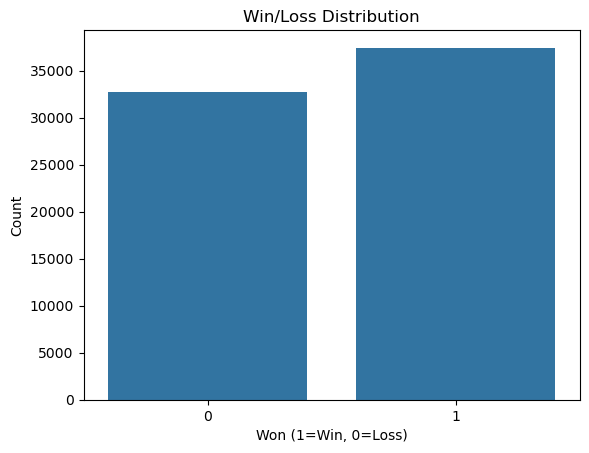

won
1    0.533183
0    0.466817
Name: proportion, dtype: float64

In [23]:
sns.countplot(x="won", data=df)
plt.title("Win/Loss Distribution")
plt.xlabel("Won (1=Win, 0=Loss)")
plt.ylabel("Count")
plt.show()

df["won"].value_counts(normalize=True)

The results show that the dataset is well-balanced, with 53.3% of the recorded games resulting in a win (1) and 46.7% resulting in a loss (0). Because the distribution is nearly 50/50, we do not suffer from a class imbalance problem. This means we can safely proceed to model training without needing to apply synthetic sampling techniques or class weighting. Furthermore, it ensures that baseline evaluation metrics, such as overall accuracy, will be reliable indicators of our models' actual performance.

### 2. What is the Distribution of Player Ratings?

This visualization is a histogram overlaid with a Kernel Density Estimate (KDE) curve and it displays the frequency distribution of player ratings (`rating`) across the dataset, to show the concentration of different skill levels within the games.

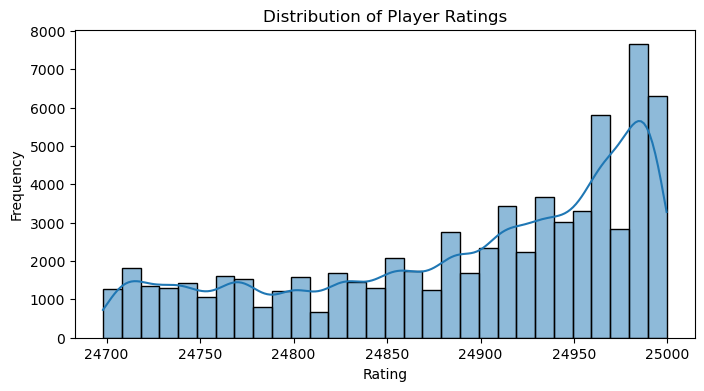

In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(df["rating"], kde=True, bins=30)
plt.title("Distribution of Player Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

The distribution of player ratings is noticeably skewed left or negatively skewed, which indicates that the bulk of the matches in our dataset are played by individuals clustered at the higher end of the rating spectrum, with a long tail extending toward the lower ratings. Contextually, this makes sense because the dataset specifically focuses on the Top 500 Tetra League players (where the maximum rating is 25,000), the majority of the data represents the elite players crowded near the rating ceiling, while relatively fewer players occupy the "lower" bounds of this top-tier bracket. 

Because the rating distribution is highly compressed, wherein everyone in this dataset is an elite player, rating alone might not be a strong predictor of who wins a match. In a completely random sample of all Tetrio players, a 5000-point rating difference would guarantee a win, but in this Top 500 dataset, a 50-point rating difference might mean nothing. This highlights the importance of our engineered gameplay features (APM, PPS, T-spin rate) to act as the primary deciders for our machine learning models to predict wins.

### 3. What is the Distrbution of Game Lengths in Seconds?

This plot also displays a histogram with a Kernel Density Estimate (KDE) overlay to visualize the overall distribution of game lengths (`duration_sec`) across all recorded matches in the dataset. It helps establish the typical pacing and lifespan of a Top 500 Tetrio match.

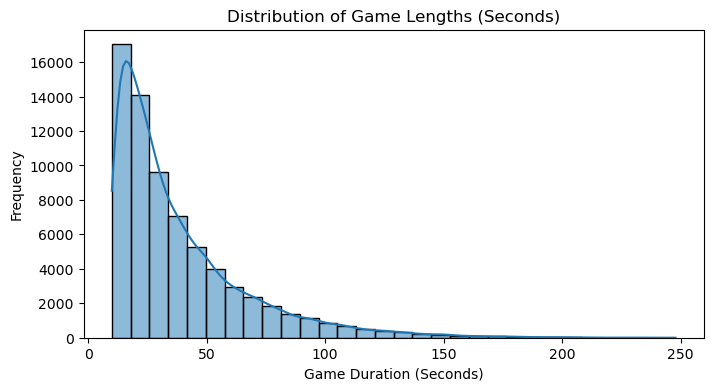

In [25]:
plt.figure(figsize=(8, 4))
sns.histplot(df["duration_sec"], kde=True, bins=30)
plt.title("Distribution of Game Lengths (Seconds)")
plt.xlabel("Game Duration (Seconds)")
plt.ylabel("Frequency")
plt.show()

The results of the graph indicates that the vast majority of Top 500 Tetrio matches are fast-paced and end relatively quickly as it is clearly right skewed. Considering Tetrio as a fast-paced competitive game and with elite gameplay, players are highly lethal, often securing knockouts in a short timeframe. The long tail extending to the right represents rare "marathon" matches where two players are perfectly matched in defense and attack, dragging the game out significantly longer than average, with the maximum almost reaching 250 seconds (4 minutes).

Because the data is right-skewed, our models must be robust to varying match lengths. A player's raw totals will naturally be much higher in the long-tail games. This visually justifies our preprocessing step of engineering rate-based features (e.g., APM, PPS) instead of using raw sums, ensuring the models evaluate player performance consistently regardless of how quickly the match ended.

### 4. What is the distribution of Pieces Per Second (PPS) and Attack Per Minute (APM)?

This visualizes the underlying distribution of two fundamental gameplay metrics, which is raw speed (Pieces per Second, or PPS) and offensive output (Attack per Minute, or APM). Histograms with Kernel Density Estimate (KDE) curves were used to examine the spread, central tendency, and shape of these features across all games in the dataset.

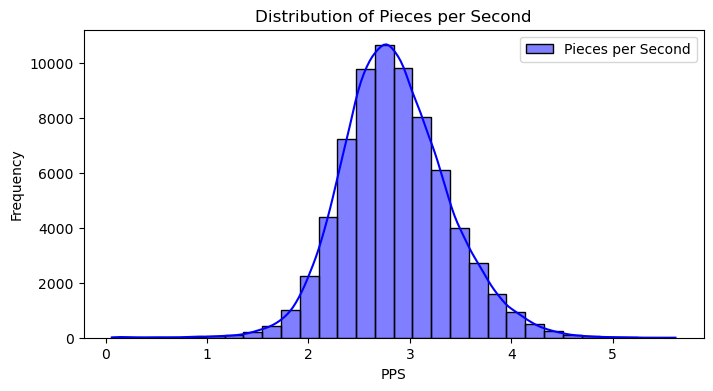

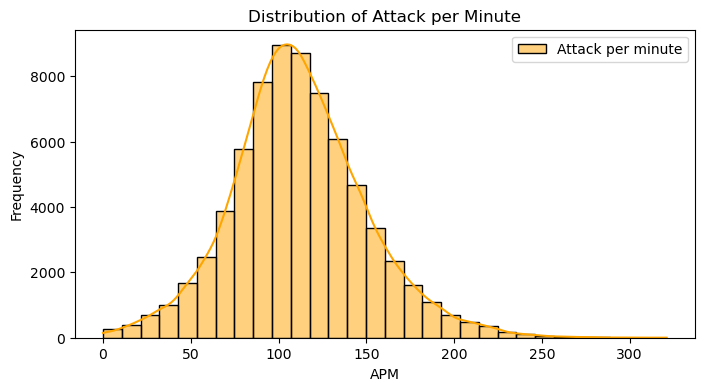

In [26]:
plt.figure(figsize=(8, 4))
sns.histplot(df["pps"], kde=True, color="blue",
             bins=30, label="Pieces per Second")
plt.title("Distribution of Pieces per Second")
plt.xlabel("PPS")
plt.ylabel("Frequency")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    df["apm"], kde=True, color="orange", bins=30, label="Attack per minute"
)
plt.title("Distribution of Attack per Minute")
plt.xlabel("APM")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The distribution of Pieces Per Second (PPS) reveals that the average Top 500 player typically drops around 2.7 pieces per second. The distribution of PPS is also highly symmetric and normally distributed around the center, with a slightly narrow spread. This indicates that at the Top 500 level, most players operate at a very similar, consistent baseline speed, with very few extremely slow or exceptionally fast outliers.

Similarly, the players' Attack Per Minute (APM) clusters around 100 APM. APM also exhibits a roughly normal distribution but is shifted slightly to the left and significantly wider spread, implying that the majority of players consistently output an average amount of damage, but pushing into the extremely high APM ranges is comparatively rarer and more difficult than achieving a high raw drop speed. This also tells us that even though these elite players are dropping pieces at the same speed, the amount of damage they output varies wildly based on their specific playstyle and efficiency.

Because PPS is centrally clustered, raw speed alone may not be the primary differentiator between a win and a loss among elite players. The models will likely prioritize how efficiently that speed is used (APM). The slight left-shift in APM suggests that players who can reach those higher, rarer attack thresholds might have a distinct, easily learned advantage.

### 5. How does average Attack Per Minute (APM) differ between winning games and losing games?

The provided exploratory data analysis (EDA) utilizes a boxplot to compare the distribution of a player's Attack Per Minute (APM) against the binary target variable, match outcome (Win vs. Loss). This visualization effectively contrasts the central tendency, interquartile spread, and extreme outlier behaviors of offensive output between winning and losing games.

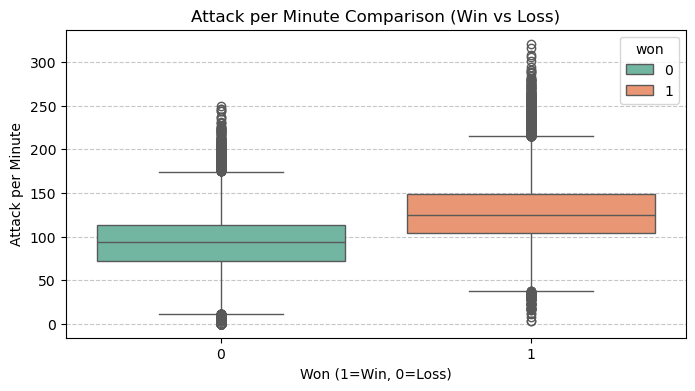

       count        mean        std       min         25%         50%  \
won                                                                     
0    32792.0   92.878400  33.093707  0.000000   72.394503   93.275076   
1    37454.0  128.271315  34.911283  2.956879  104.081684  124.247370   

            75%         max  
won                          
0    113.203440  249.566724  
1    148.330176  321.039750  


In [27]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    x="won",
    y="apm",
    data=df,
    hue="won",
    palette="Set2",
    dodge=False,
)
plt.title("Attack per Minute Comparison (Win vs Loss)")
plt.xlabel("Won (1=Win, 0=Loss)")
plt.ylabel("Attack per Minute")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print(df.groupby("won")["apm"].describe())

Looking at the boxplot, winning games exhibit a visibly higher median Attack per Minute (roughly 125 APM) compared to losing games (roughly 95 APM). This upward shift is also reflected in the entire interquartile range, where the 75th percentile for losses sits below the median for wins, indicating a positive correlation between higher APM and winning. 

While both groups display a significant number of high-value outliers, the absolute highest APM values, which approach and exceed 300, are predominantly found among the winners. However, despite this overall upward shift for winners, there is still substantial overlap between the two distributions. For instance, a player with an APM of 110 could reasonably belong to either a winning or a losing game.

Because the distributions are distinctly different, `APM` will serve as a highly valuable predictive feature that our models will rely on to calculate win probabilities. Yet, due to the substantial overlap between the distributions, APM alone is not enough and a simple threshold rule would result in many false positives and false negatives. Finally, the presence of extreme APM outliers indicates that linear models may require the APM to be scaled as to not disproportionately skew the model's weights.

### 6. Do winning games exhibit a higher average Attack Efficiency (garbage sent per piece) than losing games?

This investigates the relationship between a player's attack efficiency and the outcome of the match. It uses boxplot to visually contrast the distribution of the `attack_per_piece` feature between winning (1) and losing (0) games. Additionally, it outputs a numerical summary table using the describe() function, providing exact statistical measures—such as the mean, median, standard deviation, and quartiles—for both groups to support the visual findings.

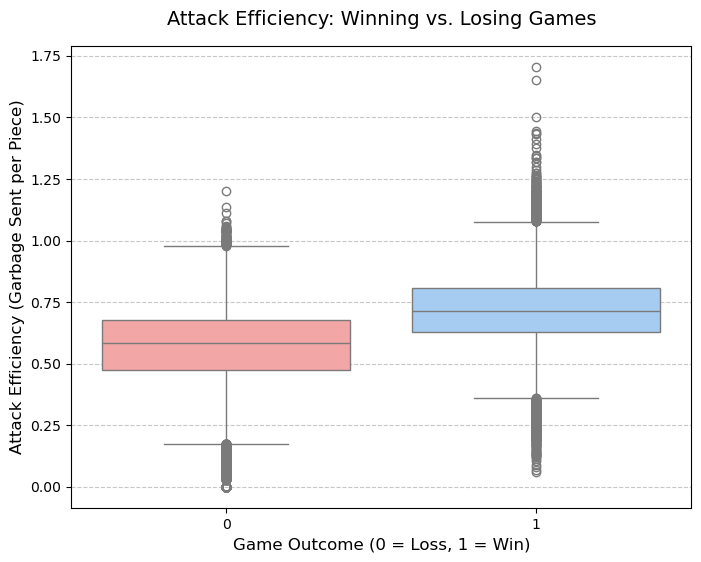

       count      mean       std       min       25%       50%       75%  \
won                                                                        
0    32792.0  0.566540  0.164676  0.000000  0.475560  0.584746  0.676471   
1    37454.0  0.717233  0.142973  0.058824  0.628099  0.715190  0.807692   

          max  
won            
0    1.200000  
1    1.705882  


In [28]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="won",
    y="attack_per_piece",
    hue="won",
    data=df,
    palette=["#FF9999", "#99CCFF"],
    legend=False
)

plt.title("Attack Efficiency: Winning vs. Losing Games", fontsize=14, pad=15)
plt.xlabel("Game Outcome (0 = Loss, 1 = Win)", fontsize=12)
plt.ylabel("Attack Efficiency (Garbage Sent per Piece)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print(df.groupby("won")["attack_per_piece"].describe())

Based on the visual boxplot, winners are significantly more efficient, with the median attack efficiency for winning games at 0.715, substantially higher than the 0.585 median for losing games. The means from the table reflect this same gap at 0.717 versus 0.566. 

There is also a clear distribution shift heavily upward for the victors as the interquartile range for wins sits between 0.628 and 0.808. Notably, the 25th percentile for winning games (0.628) is almost as high as the 75th percentile for losing games (0.676), meaning the bottom 25% of winners are roughly as efficient as the top 25% of losers. 

Furthermore, the tighter variance in winning games suggests that maintaining consistently high efficiency is a strict requirement for winning at a high level, whereas losing games exhibit a wider, more erratic spread. 

Finally, while both groups contain extreme high-end outliers, the maximum efficiency observed in a winning game (1.706) far exceeds the maximum in a losing game (1.200).

Because the distributions are distinctly separated with minimal IQR overlap, `attack_per_piece` emerges as a strong predictive feature, meaning that the models will likely assign a high weight or importance to this variable. However, despite the clear upward shift for winners, an overlap still exists in the middle of the distributions. For example, an efficiency rating of 0.65 could reasonably belong to either a win or a loss. Therefore, a model cannot rely on this feature alone and will need to cross-reference it with the other engineered metric to accurately resolve those overlapping edge cases.

### 7. How does the T-Spin Rate differ between games that were won versus games that were lost?

This investigates the relationship between a player's T-Spin rate (T-Spins executed per piece placed) and the final match outcome. The analysis pairs a visual boxplot with summary statistics to determine if high-level players rely on T-Spins to secure victories, or if alternative playstyles are equally viable.

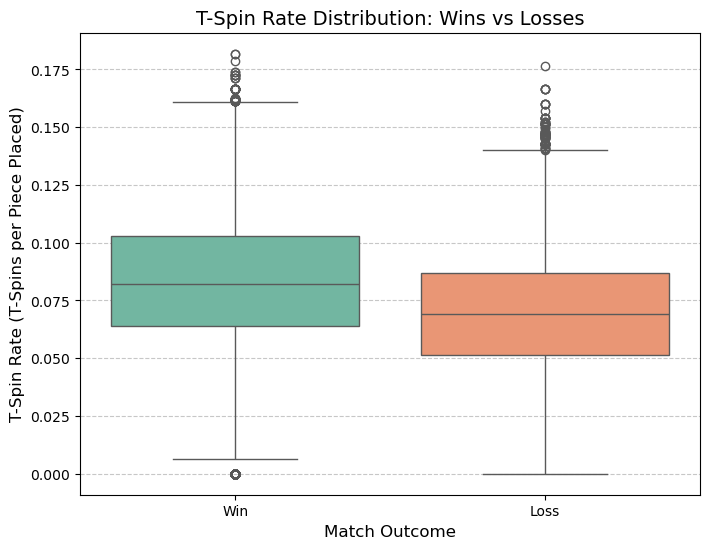

       count      mean       std  min       25%       50%       75%       max
won                                                                          
0    32792.0  0.068869  0.027943  0.0  0.051429  0.068966  0.086957  0.176471
1    37454.0  0.084047  0.028926  0.0  0.064103  0.082305  0.102941  0.181818


In [29]:
df['won_category'] = df['won'].map({0: 'Loss', 1: 'Win'})

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="won_category",
    y="tspin_rate",
    data=df,
    palette="Set2",
    hue="won_category",
    legend=False
)

plt.title("T-Spin Rate Distribution: Wins vs Losses", fontsize=14)
plt.xlabel("Match Outcome", fontsize=12)
plt.ylabel("T-Spin Rate (T-Spins per Piece Placed)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

df.drop(columns=['won_category'], inplace=True)

print(df.groupby("won")["tspin_rate"].describe())

Based on the visual distribution with the descriptive table, the median T-Spin rate in winning games (0.082) is notably higher than in losing games (0.069). On average, players who win are setting up and executing T-Spins more consistently throughout the match. 

Furthermore, The entire interquartile range is shifted upward for wins, specifically the 25th percentile for a winning game (0.064) is only slightly below the median for a losing game (0.069), meaning a "below average" winning player still T-Spins nearly as much as an "average" losing player. 

Unlike some statistics where losing games might be highly erratic, the standard deviation is remarkably similar for both wins (0.029) and losses (0.028). 

Finally, both groups have a minimum value of 0.0, indicating that it is entirely possible to win a high-level game without performing a single T-Spin, though the bulk of the data shows this is the exception rather than the rule.

Because there is a measurable upward shift in the T-spin rate for winning games, `tspin_rate` will serve as a highly valuable, discriminative feature for our models. Combined with other features, it could likely find a strong predictive power. However, because players can win with a 0 `tspin_rate`, a model will need other features to correctly classify winning games from players who use non-T-spin heavy strategies.

### 8. How does the average pressure faced (Incoming Garbage queue) compare between winning and losing games?


This analyzes the defensive pressure players face during a match by analyzing the "incoming garbage" metric. Two side-by-side boxplots accompanied by summary statistics are used to compare the distribution of Average Pressure (`incoming_garbage_mean`) and Peak Pressure (`incoming_garbage_max`) between players who lost (0) and players who won (1).

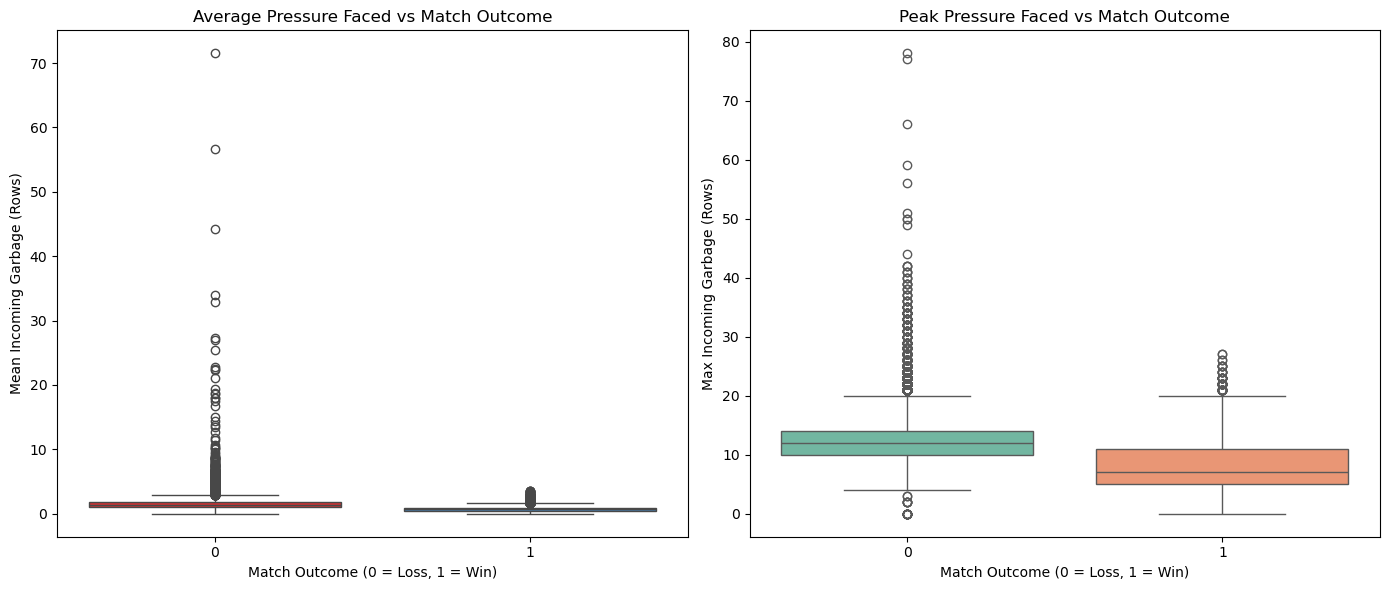

Average Pressure Faced vs Match Outcome
       count      mean       std  min       25%       50%       75%        max
won                                                                           
0    32792.0  1.545759  1.073505  0.0  1.031097  1.350971  1.806868  71.500000
1    37454.0  0.681645  0.394302  0.0  0.408537  0.658537  0.915663   3.574074

Peak Pressure Faced vs Match Outcome
       count       mean       std  min   25%   50%   75%   max
won                                                           
0    32792.0  12.013784  4.093811  0.0  10.0  12.0  14.0  78.0
1    37454.0   8.015753  3.796518  0.0   5.0   7.0  11.0  27.0


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df,
    x="won",
    y="incoming_garbage_mean",
    hue="won",
    ax=axes[0],
    palette="Set1",
    legend=False
)
axes[0].set_title("Average Pressure Faced vs Match Outcome")
axes[0].set_xlabel("Match Outcome (0 = Loss, 1 = Win)")
axes[0].set_ylabel("Mean Incoming Garbage (Rows)")

sns.boxplot(
    data=df,
    x="won",
    y="incoming_garbage_max",
    hue="won",
    ax=axes[1],
    palette="Set2",
    legend=False
)
axes[1].set_title("Peak Pressure Faced vs Match Outcome")
axes[1].set_xlabel("Match Outcome (0 = Loss, 1 = Win)")
axes[1].set_ylabel("Max Incoming Garbage (Rows)")

plt.tight_layout()

plt.show()

print("Average Pressure Faced vs Match Outcome")
print(df.groupby("won")["incoming_garbage_mean"].describe())
print("\nPeak Pressure Faced vs Match Outcome")
print(df.groupby("won")["incoming_garbage_max"].describe())

The plots and statistics tell us that across both average and peak metrics, winning games feature much lower incoming garbage. The median average pressure for a win is just 0.658 rows, compared to 1.351 rows for a loss. 

The `incoming_garbage_max` plot also shows that losing games involve absorbing massive spikes of garbage. The median peak for a loss is 12 rows, which fills more than half the board, while winners typically only face a peak of 7 rows. 

Perhaps the most notable visual element is the presence of extreme outliers in the losing category. For average incoming garbage, one losing game reached a massive 71.5 rows, while the absolute highest average for a winning game was only 3.57. Similarly, peak garbage hit a staggering 78 rows in a losing game, compared to a max of 27 for a win. This indicates that many losses are "blowouts" where the player is completely overwhelmed. 

Additionally, since these are high-level matches, the low incoming garbage for winners likely doesn't mean their opponents weren't attacking. Instead, it implies the winning players were highly efficient at canceling incoming attacks with their own offensive output before the garbage could materialize on their board.

These findings confirm that `incoming_garbage_mean` and `incoming_garbage_max` are highly predictive features. Because there is a clear, quantifiable separation in their distributions wherein winners consistently have lower values with less variance, our models will surely rely on them. Furthermore, these features will have a negative correlation with the probability of winning and the model will use high incoming garbage values as an indicator of a likely loss. However, with the extreme outliers in the losing category, transformation should be applied to not distort a model's weights.

### 9. Is there a linear relationship between a player's raw speed (PPS) and their damage output (APM)?

This investigates the linear relationship between a player's raw physical speed (Pieces Per Second or `PPS`) and their offensive damage output (Attack Per Minute or `APM`). A scatter plot with a linear regression trendline was used, and the Pearson correlation coefficient was calculated to formally quantify the strength and direction of this relationship.

Pearson Correlation Coefficient (r): 0.672
P-value: 0.000e+00


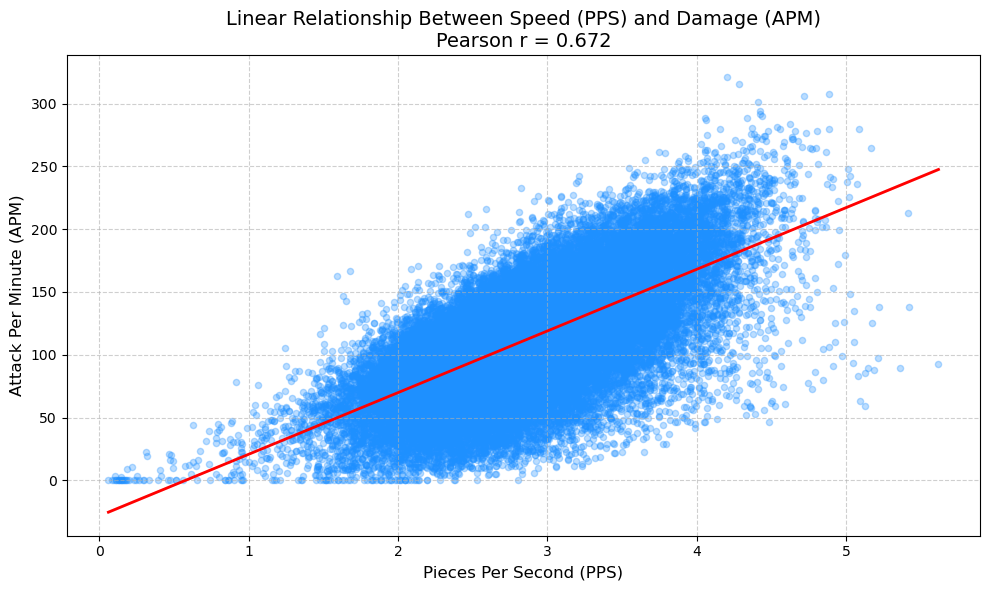

In [31]:
corr, p_value = pearsonr(df['pps'], df['apm'])
print(f"Pearson Correlation Coefficient (r): {corr:.3f}")
print(f"P-value: {p_value:.3e}")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='pps',
    y='apm',
    scatter_kws={'alpha': 0.3, 'color': 'dodgerblue', 's': 20},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title(f"Linear Relationship Between Speed (PPS) and Damage (APM)\nPearson r = {
          corr:.3f}", fontsize=14)
plt.xlabel("Pieces Per Second (PPS)", fontsize=12)
plt.ylabel("Attack Per Minute (APM)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The plot clearly and correlation coefficient value clearly indicates a strong, positive linear relationship between speed and damage. As expected, players who drop pieces faster generally send more garbage lines to their opponents. With the p-value practically being zero, this correlation is statistically significant and definitely not due to random chance within the dataset.

While the correlation is strong, it is not a perfect 1.0. The variance around the trendline means there are distinct playstyles where some players achieve high APM despite a lower PPS, possibly indicating highly efficient, deliberate setups like T-Spins, while others might have a massive PPS but lower than expected APM possibly indicating inefficient "button mashing" or survival-focused play.

Because `pps` and `apm` are strongly correlated, they share overlapping information. In a logistic regression model, this multicollinearity might make the individual feature coefficients slightly harder to interpret, as the model may arbitrarily distribute the "weight" of importance between the two. Also, the fact that they are not perfectly correlated suggests the need for complex models to look at the intersection of these two features.

### 10. Does relying heavily on maximum combo chains correlate with higher Back-to-Back (B2B) chains?

This uses a multivariate scatterplot with an overlaid linear regression trendline to maps two specific advanced gameplay mechanics against each other, which is `combo_max` (the highest consecutive sequence of any line clears) and `btb_max` (the highest consecutive sequence of "difficult" line clears, like Tetrises and T-Spins).

Pearson Correlation between Max Combo and Max B2B: -0.0088


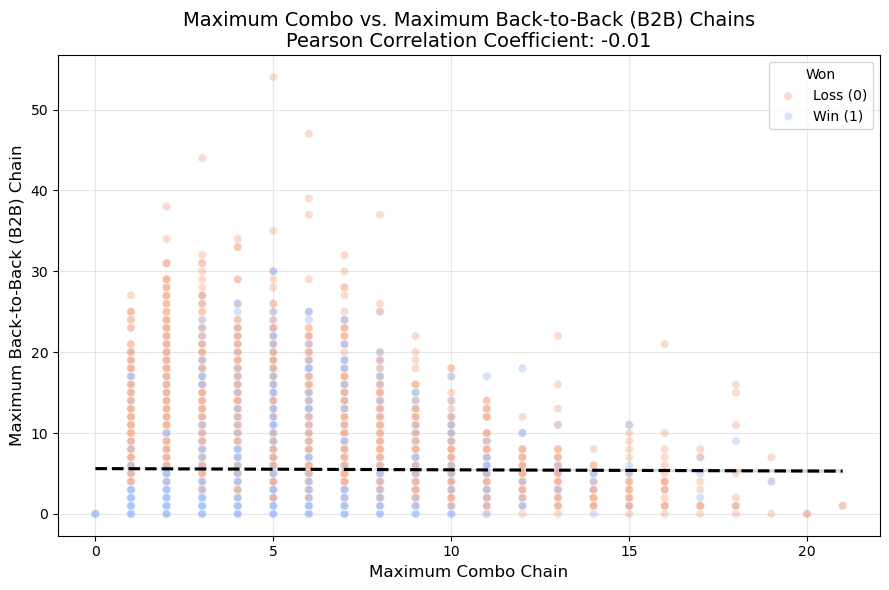

In [32]:
correlation = df["combo_max"].corr(df["btb_max"])
print(f"Pearson Correlation between Max Combo and Max B2B: {correlation:.4f}")

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="combo_max",
    y="btb_max",
    hue="won",
    alpha=0.5,
    palette="coolwarm"
)

sns.regplot(
    data=df,
    x="combo_max",
    y="btb_max",
    scatter=False,
    color='black',
    line_kws={"linestyle": "--"}
)

plt.title(f"Maximum Combo vs. Maximum Back-to-Back (B2B) Chains\nPearson Correlation Coefficient: {
          correlation:.2f}", fontsize=14)
plt.xlabel("Maximum Combo Chain", fontsize=12)
plt.ylabel("Maximum Back-to-Back (B2B) Chain", fontsize=12)
plt.legend(title="Won", labels=["Loss (0)", "Win (1)"])
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

This plot shows that an absolutely zero linear relationship exists between a player's maximum combo and their maximum B2B chain as the correlation coefficient is -0.01 and is accompanied by the flat black dashed trendline.

This makes sense because to maintain a high "combo" (clearing lines back-to-back-to-back with any piece), you usually have to break your "B2B" chain (which requires only Tetrises or T-Spins). Players generally commit to one offensive style or the other at any given moment.

Looking at the extreme ends of both axes, the highest B2B chains (above 30) and the highest Combo chains (above 15) are almost exclusively losses. This is because building a massive, singular chain requires a highly specific board state and taking significant risks. Players who focus on building one gigantic chain are likely ignoring defense, failing to downstack opponent garbage, and ultimately topping out before or shortly after they execute it.

Meanwhile, wins are heavily concentrated in the lower-to-mid ranges of both axes as consistent, moderate attacks are much more indicative of a winning game than a single massive spike.

Because the correlation is effectively zero, multicollinearity between these two features will not be an issue. A model will use these features to understand how a player attacks. For instance, if `combo_max` is high and `btb_max` is low, the model recognizes a "combo-heavy" playstyle, and vice versa. However, non-linear decision boundaries are still required to account for the fact that extreme strategies usually result in a loss

### 11. When plotting Speed (PPS) against Attack (APM), do winning games cluster in a specific region compared to losing games?

This bivariate scatterplot visualizes and investigates the relationship between a player's raw placement speed (Piece per Second or `PPS`) and their offensive damage output (Attack per Minute or `APM`).

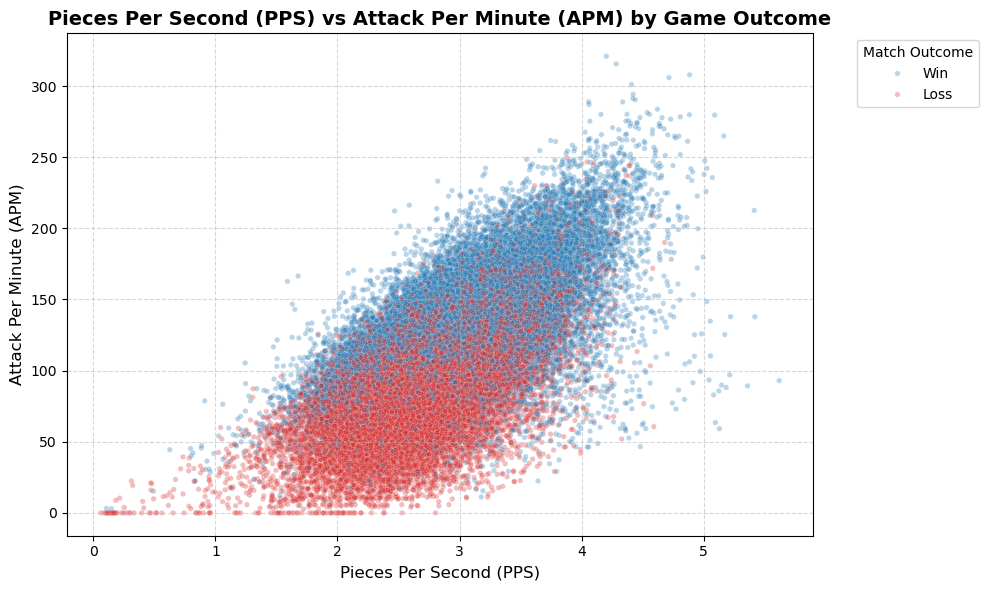

In [33]:
df['Outcome'] = df['won'].map({1: 'Win', 0: 'Loss'})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='pps',
    y='apm',
    hue='Outcome',
    palette={'Win': '#1f77b4', 'Loss': '#d62728'},
    alpha=0.3,
    s=15
)

plt.title('Pieces Per Second (PPS) vs Attack Per Minute (APM) by Game Outcome',
          fontsize=14, fontweight='bold')
plt.xlabel('Pieces Per Second (PPS)', fontsize=12)
plt.ylabel('Attack Per Minute (APM)', fontsize=12)

plt.legend(title='Match Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

df.drop(columns=['Outcome'], inplace=True)

The plot shows that while both wins and losses follow the general upward trend where faster speed = more attacks, the blue "Win" points is distinctly shifted upward compared to the red "Loss" points.

However, speed does not guarantee victory as there are a lot of overlapping points, suggesting that the quality and efficiency of piece placement or generating attacks may be the true differentiator.

We can also see that a at the bottom edge of the distribution, where players are playing fast but generating almost 0 APM, is almost entirely red (loss). These are players who are just dropping pieces to survive or misdropping heavily without completing offensive line clears. Meanwhile, the extreme upper edge of the points is almost exclusively blue, regardless of the PPS required to get there, indicating that a high APM is a near-guarantee win condition.

This visualization clearly shows that a model will require complex decision boundaries to separate the blue and red clusters accurately. This also tells us that having an `attack_per_piece` is an essential variable as it would serve a slope of these points, simplifying the decision boundary. 

---

## Model Selection

To carry out the prediction task this study used 2 classical machine learning models and 1 neural network model, specifically:

- #### k-Nearest Neighbors
- #### Logistic Regression
- #### Neural Network with a Sigmoid Activation

### Justification for Model Selection

Since our goal is a binary classification (predicting a win or loss), our chosen models are appropriate for that particular task with the proper setup and implementation.

**k-Nearest Neighbors (KNN)** is a non-parametric, distance-based algorithm. It doesn't use an equation and instead looks at a new game, finds the 'k' most statistically similar games in the training data, and predicts the majority outcome of those neighbors. In the context of our data, it can serve as a playstyle clusterer since the exploratory data analysis shows that Tetrio has distinct playstyles at the Top 500 level. kNN was chosen because it can naturally identify these non-linear "clusters." If a player has low PPS but insanely high attack efficiency, kNN will match them with similar historical games to predict their win condition, bypassing rigid linear assumptions.

**Logistic Regression** is a standard for binary classification tasks as it calculates the log-odds of an event happening based on a linear combination of features. It is also a model that not only predicts wins but explains them since it provides coefficients for every feature making it interpretable. For instance, this allows us to say exactly how much a 1-unit increase in APM or PPS increases a player's probability of winning as it assumes a straightforward relationship wherein "more efficient stats = higher chance to win."

**Neural Network** or specifically a multi-layer perceptron learns hidden, complex, and deeply non-linear interactions between variables that classical models may miss, especially since it has been observed in the exploratory data analysis that Tetrio is a game of complex, overlapping variables. For instance, a high APM might only lead to a win if the player's defensive garbage clearing is also above a certain threshold. With an appropriate activation function, optimizer, and configuration of hidden layers, it can excel at learning these complex conditional relationships. Given the that we are predicting a binary outcome, using a sigmoid activation in the output layer is a must.

For **rejecting the alternatives**, linear regression is simply designed for predicting continuous values; Naive Bayes assumes that all features are conditionally independent of each other, when in fact it is not, as observed from the exploratory data analysis where variables can be correlated. Thus, Naive Bayes' would likely suffer from degraded accuracy; While a single decision tree is highly interpretable, it is prone to overfitting, especially on datasets with continuous numerical rates. A single tree will create harsh, jagged, and highly specific cutoffs that memorize the training data but fail to generalize to the test set; Support Vector Machines, on the other hand, are incredibly powerful but scale poorly with large datasets. Given the amount of data we are dealing with, we thought that using it would be computationally expensive and painfully slow to train and tune during the validation phase, probably offering little benefit over the much faster Neural Network.

With that, we also considered our computational limitations when choosing the models and configuring them.

## Data Preparation

### Train-Validation-Test Split

We settled on a **70/15/15** split for training, validation, and testing. This is a highly effective split given the size of our dataset (70,000+ rows). Allocating 70% ensures the models have ample examples to learn complex patterns and generalize well. Allocating 15% (roughly 10,500 rows) to the validation set provides a statistically significant sample for tuning hyperparameters without overfitting. Finally, leaving an untouched 15% test set ensures a robust and unbiased final evaluation of our models.

In [34]:
X = df.drop(columns=['won'])
y = df['won']

# train split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# validation and test split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

In [35]:
print(f"Training set:   X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation set: X_val={X_val.shape},   y_val={y_val.shape}")
print(f"Test set:       X_test={X_test.shape},   y_test={y_test.shape}")

Training set:   X_train=(49172, 16), y_train=(49172,)
Validation set: X_val=(10537, 16),   y_val=(10537,)
Test set:       X_test=(10537, 16),   y_test=(10537,)


### Feature Scaling

As observed in our exploratory data analysis, it is essential to perform feature scaling on the data before proceeding to perform the machine learning task. Specifically, fitting the scaler only on the training data then transforming the validation and test sets because doing otherwise causes data leakage. Data leakage occurs when information from outside the training dataset accidentally influences the training process.

The core principle of machine learning evaluation is that the test and validation sets must represent completely unseen, real-world data and if we fit the scaler on the entire dataset before splitting, the statistical properties of the test set will influence how the training data is scaled. This allows the model to subtly 'peek' at the test set during training, leading to falsely inflated performance metrics that will not hold up when the model is evaluated on new Tetrio matches

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [37]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

X_train_scaled_df.head()

,btb_mean,btb_max,combo_mean,combo_max,immediate_garbage_mean,immediate_garbage_max,incoming_garbage_mean,incoming_garbage_max,rating,glicko,glicko_rd,duration_sec,pps,attack_per_piece,apm,tspin_rate
0,0.147545,0.434367,0.602830,0.481704,0.730153,1.407690,0.717789,0.927207,-0.029996,-0.448267,-0.062229,0.439384,-0.580616,0.443373,-0.033624,-0.003530
1,-0.799646,-0.767129,2.576991,0.992814,1.022950,0.661311,1.643701,0.476322,0.102598,-0.360330,-0.592878,-0.566186,-0.549027,0.421217,-0.030042,0.364850
2,0.098646,0.133993,-1.381681,-1.051625,-0.470950,-0.831447,-0.674647,-1.101777,-2.161196,-1.259941,3.069345,-0.639540,0.624907,-0.406538,-0.039800,1.103770
3,-0.880399,-0.767129,0.602830,0.992814,-0.482456,-0.831447,-0.632948,-0.876334,-1.544111,-1.105867,-0.771944,0.931477,0.271714,-1.150269,-0.803090,-1.228396
4,-0.038588,0.133993,0.384931,-0.029406,-0.321984,-0.333861,-0.435367,-0.650892,-1.013997,-0.930327,-0.636514,0.300367,-0.655918,0.775148,0.144130,0.552553


---